# Classement par le modèle Bradley-Terry 

Modèle de Bradley-Terry:
P(i bat j) = βᵢ / (βᵢ + βⱼ)
où βᵢ est le paramètre de « force créative » du modèle i, estimé par maximum de vraisemblance. Les ex-æquo (both_equal = True) peuvent être gérés par l’extension Davidson mais ne le seront pas dans ce notebook.

## Préparation dataset

In [262]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# notebook directory
base_dir = Path.cwd()

# Path to dataset
dataset_name = "votes.jsonl"
file_path: Path = base_dir.parent / "data" / "comparia-votes" / dataset_name

# Load the dataset
df_votes = pd.read_json(file_path, lines=True)

In [263]:
df_votes.head()

,id,timestamp,model_a_name,model_b_name,model_pair_name,chosen_model_name,opening_msg,both_equal,conversation_a,conversation_b,...,conv_incorrect_a,conv_incorrect_b,conv_superficial_a,conv_superficial_b,conv_instructions_not_followed_a,conv_instructions_not_followed_b,system_prompt_b,system_prompt_a,conv_complete_a,conv_complete_b
0,112580,2025-10-28 17:02:44.266,gemini-2.5-flash,grok-4-fast,"[gemini-2.5-flash, grok-4-fast]",None,crée des cartes types dixit sur le thème des m...,1.0,"[{'role': 'user', 'content': 'crée des cartes ...","[{'role': 'user', 'content': 'crée des cartes ...",...,False,False,False,False,False,False,None,None,False,False
1,55251,2025-04-22 18:07:44.914,gemma-3-4b,c4ai-command-r-08-2024,"[c4ai-command-r-08-2024, gemma-3-4b]",gemma-3-4b,J'ai lu quelque part (je ne sais pas où) qu'ut...,0.0,"[{'role': 'user', 'content': 'J'ai lu quelque ...","[{'role': 'user', 'content': 'J'ai lu quelque ...",...,False,False,False,True,False,False,None,None,True,False
2,56377,2025-04-28 08:47:19.683,phi-4,llama-3.1-405b,"[llama-3.1-405b, phi-4]",None,créer un texte sur le degrés d'intégration des...,1.0,"[{'role': 'user', 'content': 'créer un texte s...","[{'role': 'user', 'content': 'créer un texte s...",...,False,False,False,False,False,False,None,None,False,False
3,64275,2025-05-17 05:45:36.035,phi-4,gemma-3-27b,"[gemma-3-27b, phi-4]",gemma-3-27b,Coucou,0.0,"[{'role': 'user', 'content': 'Coucou '}, {'rol...","[{'role': 'user', 'content': 'Coucou '}, {'rol...",...,False,False,False,False,False,False,None,None,False,False
4,30173,2025-02-24 15:05:34.404,chocolatine-2-14b-instruct-v2.0.3-q8,gpt-4o-2024-08-06,"[chocolatine-2-14b-instruct-v2.0.3-q8, gpt-4o-...",gpt-4o-2024-08-06,Je souhaite élaborer des routines qui me perme...,0.0,"[{'role': 'system', 'content': 'Tu es un assis...","[{'role': 'user', 'content': 'Je souhaite élab...",...,False,False,False,False,False,False,,Tu es un assistant IA serviable et bienveillan...,False,False


In [264]:
df_votes.columns

Index(['id', 'timestamp', 'model_a_name', 'model_b_name', 'model_pair_name',
       'chosen_model_name', 'opening_msg', 'both_equal', 'conversation_a',
       'conversation_b', 'conv_turns', 'selected_category',
       'is_unedited_prompt', 'conversation_pair_id', 'session_hash',
       'visitor_id', 'conv_comments_a', 'conv_comments_b', 'conv_useful_a',
       'conv_useful_b', 'conv_creative_a', 'conv_creative_b',
       'conv_clear_formatting_a', 'conv_clear_formatting_b',
       'conv_incorrect_a', 'conv_incorrect_b', 'conv_superficial_a',
       'conv_superficial_b', 'conv_instructions_not_followed_a',
       'conv_instructions_not_followed_b', 'system_prompt_b',
       'system_prompt_a', 'conv_complete_a', 'conv_complete_b'],
      dtype='object')

In [265]:
number_of_chosen_models = len(df_votes["chosen_model_name"].value_counts())
""" The number of different models that got elected by the jury """

print(f"Nombre de modèles différents choisis par le jury: {number_of_chosen_models}")

Nombre de modèles différents choisis par le jury: 109


In [266]:
df_votes.shape

(162858, 34)

In [267]:
df_votes["selected_category"].value_counts()

selected_category
explanations       2133
ideas              1494
iasummit           1292
recipes             983
stories             931
recommendations     864
administrative      856
coach               737
languages           442
Name: count, dtype: int64

les colones qui nous intéressent sont :
- Pour l'étude par Bradley-Terry globale :
    - model_a_name : le nom du modèle A
    - model_b_name : le nom du modèle B
    - both_equal : indique si les deux modèles sont jugés égaux
    - chosen_model_name : le modèle choisi par le juge
- Pour l'étude par Bradley-Terry sur les conversations créatives :
    - conv_creative_a: la conversation associée au modèle A est elle créative ou non
    - conv_creative_b: la conversation associée au modèle B est elle créative ou non

In [268]:
selected_columns: list[str] = [
    "model_a_name", "model_b_name",
    "chosen_model_name", "both_equal",
    "conv_creative_a", "conv_creative_b"
]

df_votes = df_votes[selected_columns]
df_votes.head()

,model_a_name,model_b_name,chosen_model_name,both_equal,conv_creative_a,conv_creative_b
0,gemini-2.5-flash,grok-4-fast,None,1.0,False,False
1,gemma-3-4b,c4ai-command-r-08-2024,gemma-3-4b,0.0,False,False
2,phi-4,llama-3.1-405b,None,1.0,False,False
3,phi-4,gemma-3-27b,gemma-3-27b,0.0,False,False
4,chocolatine-2-14b-instruct-v2.0.3-q8,gpt-4o-2024-08-06,gpt-4o-2024-08-06,0.0,False,False


Nettoyage des données : vérifier les valeurs manquantes, les incohérences, les doublons, etc. et nettoyer le dataset en conséquence pour s'assurer que les données utilisées pour le classement sont fiables et cohérentes.

In [269]:
df_votes.isnull().sum()

model_a_name             0
model_b_name             0
chosen_model_name    54632
both_equal           13128
conv_creative_a          0
conv_creative_b          0
dtype: int64

In [270]:
no_selection_mask = (
        df_votes['chosen_model_name'].isnull() &
        (df_votes['both_equal'] == 0)
)
nb_not_selected = no_selection_mask.sum()
print(f"Il y a {nb_not_selected} entrées où aucun modèle n'est préféré ou ex-aequo.")

Il y a 0 entrées où aucun modèle n'est préféré ou ex-aequo.


On doit retirer :
- Les ex-aequos (both_equal = True) car on ne va pas les prendre en compte dans le classement de Bradley-Terry
- Les entrées où le juge n'a pas exprimé de préférence

In [271]:
print(f"Nombre de ex-aequos à retirer : "
      f"{(df_votes['both_equal'] == 1).sum()} sur {len(df_votes)} entrées "
      f"({100 * (df_votes['both_equal'] == 1).sum() / len(df_votes):.2f}%)"
      )
df_votes_clean = df_votes[
    (df_votes['both_equal'] == 0) &
    df_votes['chosen_model_name'].notna() &
    (df_votes['model_a_name'] != df_votes['model_b_name'])  # ← à ajouter
]

print(f"Lignes avant: {len(df_votes)}")
print(f"Lignes aprés: {len(df_votes_clean)}")
print(f"Supprimées:   {len(df_votes) - len(df_votes_clean)} "
      f"({100 * (len(df_votes) - len(df_votes_clean)) / len(df_votes):.2f}%)")

Lignes avant: 162858
Lignes aprés: 98782
Supprimées:   64076 (39.34%)


99,019  → avec gagnant clair       (61.8%)
50,711  → ex-aequos                (31.1%)
13,128  → sans préférence exprimée  (8.1%)

On va également vérifier que les valeurs de chosen_model_name sont bien cohérentes avec les modèles en compétition (model_a_name et model_b_name) pour s'assurer qu'il n'y a pas d'erreurs de saisie ou d'incohérences dans les données.

In [272]:
assert df_votes_clean['chosen_model_name'].isin(
    df_votes_clean['model_a_name'].tolist() + df_votes_clean['model_b_name'].tolist()
).all(), "chosen_model_name contains unexpected values"

In [273]:
valid_mask = (
    (df_votes_clean['chosen_model_name'] == df_votes_clean['model_a_name']) |
    (df_votes_clean['chosen_model_name'] == df_votes_clean['model_b_name'])
)

invalid = df_votes_clean[~valid_mask]
if len(invalid) == 0:
    print("Chaque chosen_model_name est bien model_a_name ou model_b_name")
else:
    print(f"!!! {len(invalid)} lignes invalides détectées :")
    print(invalid[['model_a_name', 'model_b_name', 'chosen_model_name']].head(10))

Chaque chosen_model_name est bien model_a_name ou model_b_name


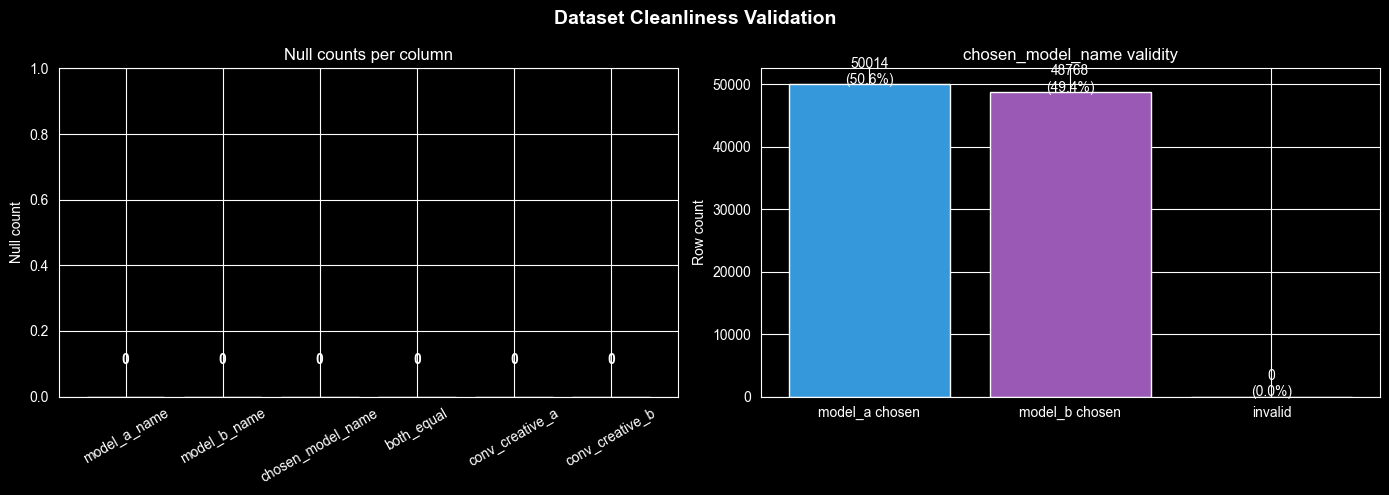

In [274]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Dataset Cleanliness Validation", fontsize=14, fontweight='bold')

# --- Plot 1 : Null counts par colonne ---
null_counts = df_votes_clean.isnull().sum()
colors = ['#2ecc71' if v == 0 else '#e74c3c' for v in null_counts.values]

axes[0].bar(null_counts.index, null_counts.values, color=colors)
axes[0].set_title("Null counts per column")
axes[0].set_ylabel("Null count")
axes[0].set_ylim(0, max(1, null_counts.max() + 1))  # évite ylim=0 si tout est clean
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(null_counts.values):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontsize=10, fontweight='bold')

# --- Plot 2 : Validité de chosen_model_name ---
is_model_a = (df_votes_clean['chosen_model_name'] == df_votes_clean['model_a_name'])
is_model_b = (df_votes_clean['chosen_model_name'] == df_votes_clean['model_b_name'])
is_invalid = ~(is_model_a | is_model_b)

counts = {
    'model_a chosen': is_model_a.sum(),
    'model_b chosen': is_model_b.sum(),
    'invalid':        is_invalid.sum(),
}
bar_colors = ['#3498db', '#9b59b6', '#e74c3c']

axes[1].bar(counts.keys(), counts.values(), color=bar_colors)
axes[1].set_title("chosen_model_name validity")
axes[1].set_ylabel("Row count")
for i, (k, v) in enumerate(counts.items()):
    axes[1].text(i, v + 50, f"{v}\n({100*v/len(df_votes_clean):.1f}%)", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [275]:
df_votes_clean = df_votes_clean.astype({
    'both_equal': 'int8',        # 0/1 : int8 suffit, économise de la mémoire
    'model_a_name': 'category',  # strings répétitifs : category plus efficace
    'model_b_name': 'category',
    'chosen_model_name': 'category',
})
df_votes_clean.dtypes

model_a_name         category
model_b_name         category
chosen_model_name    category
both_equal               int8
conv_creative_a          bool
conv_creative_b          bool
dtype: object

In [276]:
# On écrase df_votes avec sa version clean, sauvons la RAM.
df_votes = df_votes_clean
del df_votes_clean
gc.collect()

15948

# Analyse de Bradley-Terry.

In [277]:
models_tested = pd.unique(df_votes[["model_a_name", "model_b_name"]].values.ravel())
print(len(models_tested))

105


In [278]:
model_test_counts = (
    pd.concat([
        df_votes["model_a_name"].rename("model"),
        df_votes["model_b_name"].rename("model"),
    ])
    .value_counts()
    .reset_index()
    .rename(columns={"count": "test_count"})
    .sort_values("test_count", ascending=False)
)

print(model_test_counts)

                        model  test_count
0                  gemma-3-4b        5344
1               llama-3.3-70b        5292
2                 gemma-3-27b        4856
3                       phi-4        4804
4                 gemma-3-12b        4764
..                        ...         ...
100        mistral-medium-3.1          86
101         gemma-2-27b-it-q8          85
102           jamba-1.5-large          76
103       qwen2.5-7b-instruct          53
104  Apertus-8B-Instruct-2509          34

[105 rows x 2 columns]


On a une bonne représentation des modèles, même si les derniers trés variable. Vérifions que le graph est fortement connecté pour appliquer le modèle de Bradley-Terry.

In [279]:
import networkx as nx

G = nx.from_pandas_edgelist(
    df_votes,
    source="model_a_name",
    target="model_b_name",
    create_using=nx.DiGraph()
)

print(f"Nœuds  : {G.number_of_nodes()}")
print(f"Arêtes : {G.number_of_edges()}")
print(f"Fortement connexe : {nx.is_strongly_connected(G)}")


Arêtes : 5268
Fortement connexe : True


On a un graph fortement connexe, on peut appliquer le modèle de Bradley-Terry aprés cette validation.

## Construction de la matrice de comparaisons
Top N seulement

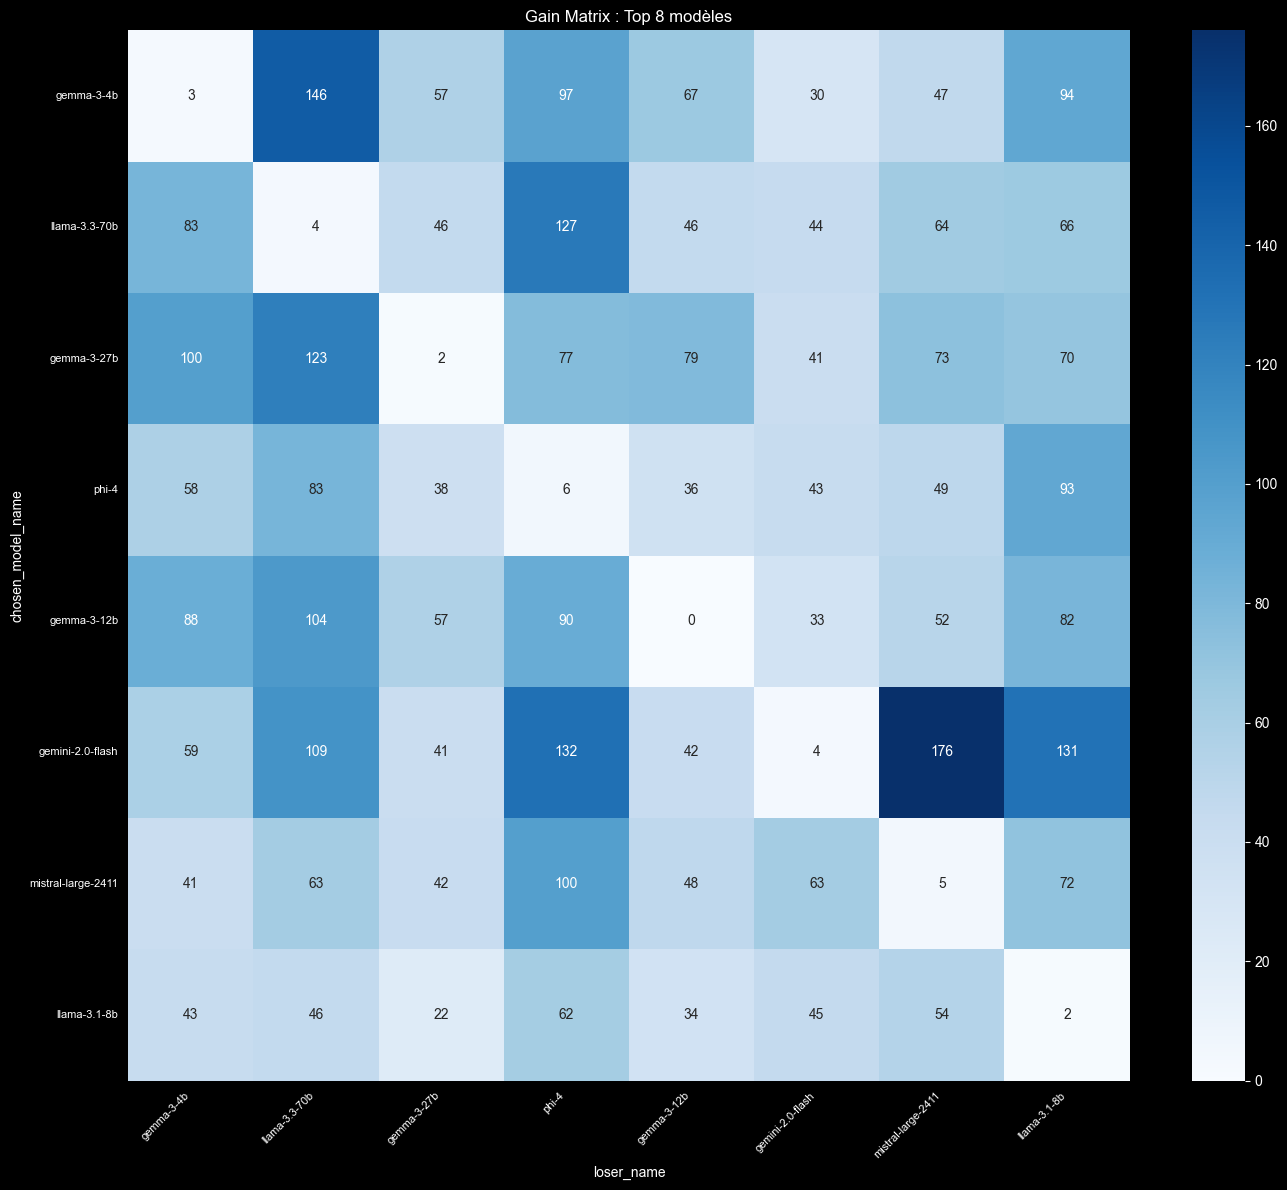

In [280]:
TOP_N = 8
top_models = model_test_counts["model"].head(TOP_N).tolist()

gain_matrix_top = gain_matrix_fast.loc[top_models, top_models]

plt.figure(figsize=(14, 12))
sns.heatmap(gain_matrix_top, annot=True, fmt="d", cmap="Blues")
plt.title(f"Gain Matrix : Top {TOP_N} modèles")
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

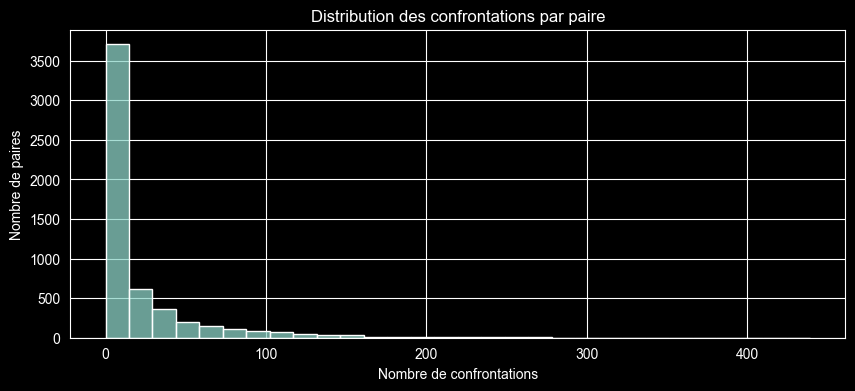

In [281]:
# Distribution du nombre de confrontations par paire de modèles
pair_counts = (gain_matrix_fast + gain_matrix_fast.T)

# Paires qui ne se sont jamais affrontées
never_met = (pair_counts == 0).sum().sum() // 2  # divise par 2 (matrice symétrique)
print(f"Paires sans confrontation : {never_met} / {105*104//2} possibles")

plt.figure(figsize=(10, 4))
vals = pair_counts.values[np.triu_indices_from(pair_counts.values, k=1)]  # triangle supérieur
sns.histplot(vals, bins=30)
plt.title("Distribution des confrontations par paire")
plt.xlabel("Nombre de confrontations")
plt.ylabel("Nombre de paires")
plt.show()

On a une distribution "long tail" avec beaucoup de paires qui ne se sont jamais affrontées ou très peu, et quelques paires qui se sont affrontées de nombreuses fois. Cela peut poser des problèmes pour l'estimation du modèle de Bradley-Terry, car les paires avec peu ou pas de confrontations fournissent peu d'informations pour estimer les paramètres de force relative des modèles.

In [282]:
vals = pair_counts.values[np.triu_indices_from(pair_counts.values, k=1)]
print(f"Paires à 0 confrontations : {(vals == 0).sum()}")
print(f"Paires à < 5 confrontations : {(vals < 5).sum()}")
print(f"Médiane : {np.median(vals):.0f}")
print(f"Moyenne : {np.mean(vals):.1f}")

Paires à 0 confrontations : 2708
Paires à < 5 confrontations : 3046
Médiane : 1
Moyenne : 19.7


Plus de la moitié des paires ne se sont affrontées qu'une seule fois ou jamais. C'est sparse mais pas problématique pour Bradely-Terry grâce à la connectivité transitive qu'on a vérifiée.
Pour rappel on a :
1. Graphe fortement connexe : le MLE BT est bien défini pour tous les 105 modèles, pas de problème mathématique.
2. Minimum à 53 apparitions : aucun modèle n'est vraiment sous-représenté, même les 4 en queue ont assez de signal.
3. La sparsité des paires est normale : avec 105 modèles, avoir toutes les paires bien représentées est impossible sans des millions de votes. BT est précisément conçu pour gérer ça via la transitivité.

In [283]:
df_votes['loser_name'] = np.where(
    df_votes['chosen_model_name'] == df_votes['model_a_name'],
    df_votes['model_b_name'],
    df_votes['model_a_name']
)

gain_matrix = pd.crosstab(
    df_votes['chosen_model_name'],
    df_votes['loser_name']
)

# S'assurer que la matrice est carrée avec tous les modèles
all_models = sorted(df_votes['model_a_name'].unique().tolist() +
                    df_votes['model_b_name'].unique().tolist())
all_models = sorted(set(all_models))

gain_matrix = gain_matrix.reindex(index=all_models, columns=all_models, fill_value=0)

print(f"Shape: {gain_matrix.shape}")  # (105, 105)
assert gain_matrix.shape == (105, 105)
assert (gain_matrix.values.diagonal() == 0).all()  # un modèle ne se bat pas contre lui-même

## 9.	Classement global : basé sur tous les votes de comparia-votes (chosen_model_name, both_equal).

### Implémentation du modèle de Bradley-Terry

On va estimer les paramètres $\beta_i$ par maximum de vraisemblance via l'algorithme itératif de Zermelo (MM algorithm) :

$$\beta_i^{(t+1)} = \frac{w_i}{\sum_{j \neq i} \frac{n_{ij}}{\beta_i^{(t)} + \beta_j^{(t)}}}$$

où :
- $w_i$ est le nombre total de victoires du modèle $i$
- $n_{ij}$ est le nombre total de confrontations entre $i$ et $j$

In [308]:
def bradley_terry_mle_iter(gain_matrix, max_iter=1000, tol=1e-8):
    """
    Estime les paramètres du modèle de Bradley-Terry par l'algorithme MM (Zermelo).
    
    Parameters
    ----------
    gain_matrix : pd.DataFrame
        Matrice carrée W où W[i,j] = nombre de victoires de i contre j
    max_iter : int
        Nombre maximum d'itérations
    tol : float
        Seuil de convergence
    
    Returns
    -------
    beta : pd.Series
        Paramètres de force estimés (normalisés pour sommer à 1)
    log_likelihoods : list
        Log-vraisemblance à chaque itération
    """
    models = gain_matrix.index.tolist()
    n = len(models)
    W = gain_matrix.values.astype(float)
    
    # Nombre total de confrontations entre i et j
    N = W + W.T
    
    # Nombre total de victoires par modèle
    wins = W.sum(axis=1)
    
    # Initialisation uniforme
    beta = np.ones(n) / n
    
    log_likelihoods = []
    
    for iteration in range(max_iter):
        beta_old = beta.copy()
        
        # Calcul de la log-vraisemblance
        ll = 0
        for i in range(n):
            for j in range(i+1, n):
                if N[i, j] > 0:
                    ll += W[i, j] * np.log(beta[i]) + W[j, i] * np.log(beta[j])
                    ll -= N[i, j] * np.log(beta[i] + beta[j])
        log_likelihoods.append(ll)
        
        # Mise à jour MM (Zermelo)
        for i in range(n):
            denom = 0
            for j in range(n):
                if i != j and N[i, j] > 0:
                    denom += N[i, j] / (beta[i] + beta[j])
            if denom > 0:
                beta[i] = wins[i] / denom
        
        # Normalisation pour que la somme = 1
        beta = beta / beta.sum()
        
        # Vérification de convergence
        if np.max(np.abs(beta - beta_old)) < tol:
            print(f"Convergence atteinte après {iteration + 1} itérations")
            break
    else:
        print(f"Pas de convergence après {max_iter} itérations")
    
    beta_series = pd.Series(beta, index=models)
    return beta_series, log_likelihoods

In [309]:
def bradley_terry_mle(gain_matrix: pd.DataFrame, max_iter: int = 1000, tol: float = 1e-8):
    """
    Estime les paramètres du modèle de Bradley-Terry par l'algorithme MM (Zermelo).
    Implémentation fully vectorisée via numpy.

    Parameters
    ----------
    gain_matrix : pd.DataFrame
        Matrice carrée W où W[i,j] = nombre de victoires de i contre j
    max_iter : int
        Nombre maximum d'itérations
    tol : float
        Seuil de convergence

    Returns
    -------
    beta : pd.Series
        Paramètres de force estimés (normalisés pour sommer à 1)
    log_likelihoods : list[float]
        Log-vraisemblance à chaque itération
    """
    models = gain_matrix.index.tolist()
    W = gain_matrix.values.astype(float)
    N = W + W.T                      # N[i,j] = total confrontations i vs j
    wins = W.sum(axis=1)             # total victoires par modèle

    beta = np.ones(len(models)) / len(models)
    log_likelihoods = []

    for iteration in range(max_iter):
        beta_old = beta.copy()

        # Log-vraisemblance vectorisée — shape (n, n)
        beta_sum = beta[:, None] + beta[None, :]          # beta[i] + beta[j]
        with np.errstate(divide='ignore', invalid='ignore'):
            ll_matrix = np.where(
                N > 0,
                W * np.log(np.where(beta[:, None] > 0, beta[:, None], 1)) -
                N * np.log(np.where(beta_sum > 0, beta_sum, 1)),
                0.0
            )
        # Triangle supérieur seulement pour éviter double comptage
        ll = np.triu(ll_matrix, k=1).sum()
        log_likelihoods.append(ll)

        # Mise à jour MM vectorisée
        # denom[i] = sum_j N[i,j] / (beta[i] + beta[j])
        with np.errstate(invalid='ignore'):
            denom = np.where(N > 0, N / beta_sum, 0.0).sum(axis=1)

        beta = np.where(denom > 0, wins / denom, 0.0)
        beta /= beta.sum()

        if np.max(np.abs(beta - beta_old)) < tol:
            print(f"Convergence atteinte après {iteration + 1} itérations")
            break
    else:
        print(f"Pas de convergence après {max_iter} itérations")

    return pd.Series(beta, index=models), log_likelihoods

In [311]:
beta, log_likelihoods = bradley_terry_mle(gain_matrix)

ranking = beta.sort_values(ascending=False).reset_index()
ranking.columns = ['model', 'beta']
ranking['rank'] = ranking.index + 1

print("\n=== Classement Bradley-Terry (paramètre β) ===")
for _, row in ranking.iterrows():
    print(f"{row['rank']:3d}. {row['model']:40s} β = {row['beta']:.6f}")

Convergence atteinte après 115 itérations

=== Classement Bradley-Terry (paramètre β) ===
  1. gemini-3.1-flash-lite-preview            β = 0.022074
  2. mistral-large-2512                       β = 0.020406
  3. mistral-medium-3.1                       β = 0.020303
  4. gemini-3-flash-preview                   β = 0.020298
  5. mistral-medium-2508                      β = 0.020252
  6. gemini-2.5-flash                         β = 0.019768
  7. gemini-3.1-pro-preview                   β = 0.018420
  8. mistral-small-2603                       β = 0.018160
  9. qwen3-max-2025-09-23                     β = 0.017740
 10. magistral-medium                         β = 0.017395
 11. claude-4-6-sonnet                        β = 0.016345
 12. gemini-2.0-flash                         β = 0.016081
 13. gemini-3-pro-preview                     β = 0.015886
 14. gpt-5.4                                  β = 0.015331
 15. deepseek-v3-0324                         β = 0.014886
 16. gpt-5.4-nano        

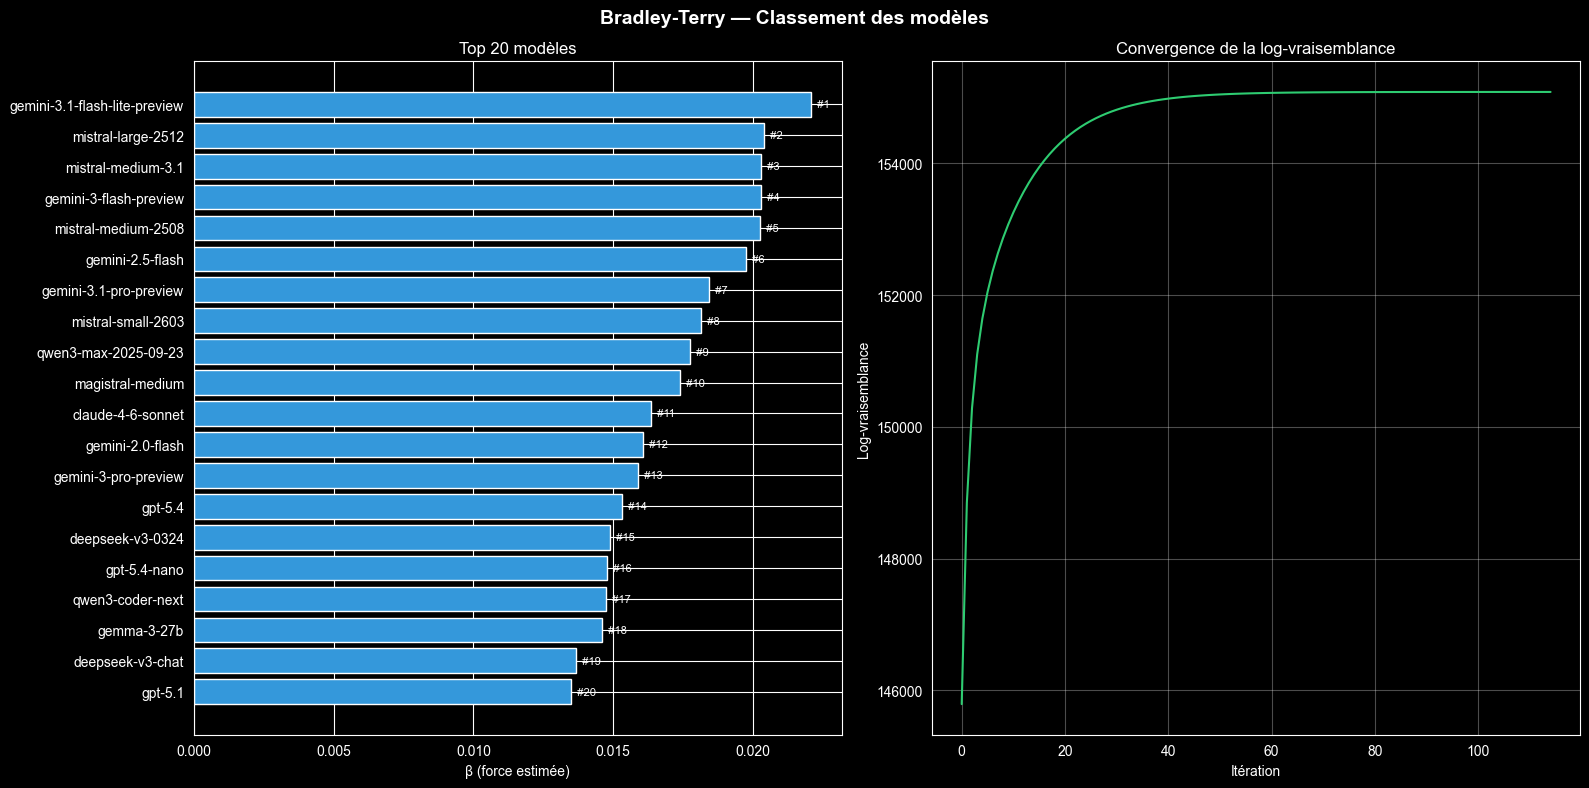

In [312]:
TOP_N = 20

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle("Bradley-Terry — Classement des modèles", fontsize=14, fontweight='bold')

# --- Top N ---
top = ranking.head(TOP_N)
axes[0].barh(top['model'][::-1], top['beta'][::-1], color='#3498db')
axes[0].set_title(f"Top {TOP_N} modèles")
axes[0].set_xlabel("β (force estimée)")
for i, (_, row) in enumerate(top[::-1].iterrows()):
    axes[0].text(row['beta'], i, f"  #{row['rank']}", va='center', fontsize=8)

# --- Convergence ---
axes[1].plot(log_likelihoods, color='#2ecc71', linewidth=1.5)
axes[1].set_title("Convergence de la log-vraisemblance")
axes[1].set_xlabel("Itération")
axes[1].set_ylabel("Log-vraisemblance")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10.	Classement créativité : basé uniquement sur les conversations où conv_creative_a ou conv_creative_b est True.

On va filtrer le dataset pour ne garder que les conversations où au moins un des deux modèles a un label de créativité True, puis refaire le classement de Bradley-Terry sur ce sous-ensemble de données pour voir si le classement change lorsque l'on se concentre uniquement sur les conversations créatives.
On refait les tests de connectivité également, pour s'assurer que BT soit cohérent.

In [313]:
# --- Filtre créatif ---
creative_mask = df_votes["conv_creative_a"] | df_votes["conv_creative_b"]
df_votes_creative = df_votes[creative_mask]

print(f"Votes créatifs  : {len(df_votes_creative)} / {len(df_votes)} ({100*creative_mask.mean():.1f}%)")

# --- Modèles uniques ---
models_creative = pd.unique(df_votes_creative[["model_a_name", "model_b_name"]].values.ravel())
print(f"Modèles uniques : {len(models_creative)} / {len(pd.unique(df_votes[['model_a_name', 'model_b_name']].values.ravel()))}")

# --- Connectivité ---
G_creative = nx.from_pandas_edgelist(
    df_votes_creative,
    source="model_a_name",
    target="model_b_name",
    create_using=nx.DiGraph()
)
is_connected = nx.is_strongly_connected(G_creative)
print(f"Fortement connexe : {is_connected}")

if not is_connected:
    largest_scc = max(nx.strongly_connected_components(G_creative), key=len)
    missing = set(models_creative) - largest_scc
    print(f"Modèles hors SCC principale ({len(missing)}) : {missing}")

Votes créatifs  : 8065 / 98782 (8.2%)
Modèles uniques : 102 / 105
Fortement connexe : True


In [314]:
# --- Gain matrix créative ---
df_votes_creative = df_votes_creative.copy()
df_votes_creative['loser_name'] = np.where(
    df_votes_creative['chosen_model_name'] == df_votes_creative['model_a_name'],
    df_votes_creative['model_b_name'],
    df_votes_creative['model_a_name']
)

gain_matrix_creative = pd.crosstab(
    df_votes_creative['chosen_model_name'],
    df_votes_creative['loser_name']
)

models_creative_sorted = sorted(models_creative.tolist())
gain_matrix_creative = gain_matrix_creative.reindex(
    index=models_creative_sorted,
    columns=models_creative_sorted,
    fill_value=0
)

assert (gain_matrix_creative.values.diagonal() == 0).all(), "Self-comparaisons détectées !"
print(f"Shape : {gain_matrix_creative.shape}")  # (102, 102)

# --- BT créatif ---
beta_creative, log_likelihoods_creative = bradley_terry_mle(gain_matrix_creative)

ranking_creative = beta_creative.sort_values(ascending=False).reset_index()
ranking_creative.columns = ['model', 'beta_creative']
ranking_creative['rank_creative'] = ranking_creative.index + 1

print(ranking_creative.head(10))

Shape : (102, 102)
Convergence atteinte après 169 itérations
                           model  beta_creative  rank_creative
0               magistral-medium       0.033364              1
1                   gpt-5.4-mini       0.029226              2
2               qwen3-coder-next       0.028553              3
3            mistral-medium-2508       0.028396              4
4  gemini-3.1-flash-lite-preview       0.026371              5
5                   gpt-5.4-nano       0.025236              6
6         gemini-3.1-pro-preview       0.022440              7
7              qwen3.5-397b-a17b       0.020412              8
8             mistral-large-2512       0.020077              9
9             deepseek-chat-v3.1       0.020022             10


On garde seulement celle qui ont au moins un des deux modèles avec un label de créativité True et on refait le classement de Bradley-Terry sur ce sous-ensemble de données pour voir si le classement change lorsque l'on se concentre uniquement sur les conversations créatives.

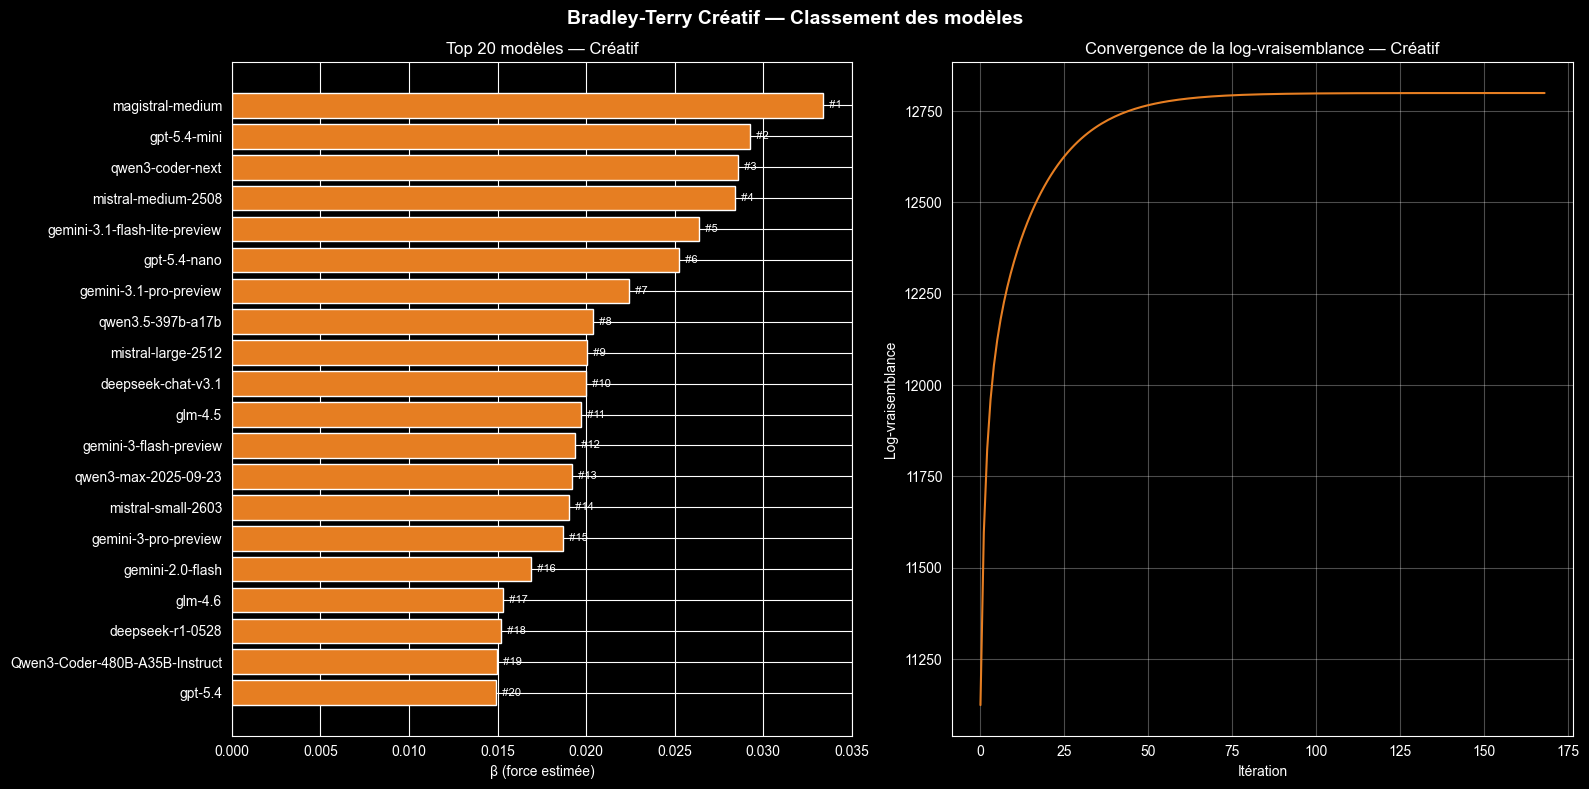

In [315]:
TOP_N = 20

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle("Bradley-Terry Créatif — Classement des modèles", fontsize=14, fontweight='bold')

# --- Top N créatif ---
top_creative = ranking_creative.head(TOP_N)
axes[0].barh(top_creative['model'][::-1], top_creative['beta_creative'][::-1], color='#e67e22')
axes[0].set_title(f"Top {TOP_N} modèles — Créatif")
axes[0].set_xlabel("β (force estimée)")
for i, (_, row) in enumerate(top_creative[::-1].iterrows()):
    axes[0].text(row['beta_creative'], i, f"  #{row['rank_creative']}", va='center', fontsize=8)

# --- Convergence ---
axes[1].plot(log_likelihoods_creative, color='#e67e22', linewidth=1.5)
axes[1].set_title("Convergence de la log-vraisemblance — Créatif")
axes[1].set_xlabel("Itération")
axes[1].set_ylabel("Log-vraisemblance")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11.	Comparez les deux classements (Spearman ρ, visualisation). Quels modèles montent ou descendent significativement ?

In [316]:
from scipy.stats import spearmanr

# Merge sur les modèles communs aux deux rankings
ranking_merged = ranking.merge(
    ranking_creative,
    on='model',
    how='inner'  # uniquement les 102 modèles présents dans les deux
)

print(f"Modèles en commun : {len(ranking_merged)}")
print(f"Modèles absents du créatif : {len(ranking) - len(ranking_merged)}")
ranking_merged.head()

,model,beta,rank,beta_creative,rank_creative
0,gemini-3.1-flash-lite-preview,0.022074,1,0.026371,5
1,mistral-large-2512,0.020406,2,0.020077,9
2,gemini-3-flash-preview,0.020298,4,0.019373,12
3,mistral-medium-2508,0.020252,5,0.028396,4
4,gemini-2.5-flash,0.019768,6,0.014588,23


In [317]:
rho, pvalue = spearmanr(ranking_merged['rank'], ranking_merged['rank_creative'])
print(f"Spearman ρ  : {rho:.4f}")
print(f"p-value     : {pvalue:.4e}")
print(f"Corrélation : {'forte' if abs(rho) > 0.7 else 'modérée' if abs(rho) > 0.4 else 'faible'}")

# Delta de rang : modèles qui montent/descendent significativement
ranking_merged['delta_rank'] = ranking_merged['rank'] - ranking_merged['rank_creative']
ranking_merged = ranking_merged.sort_values('delta_rank', ascending=False)

print("\n=== Modèles qui montent en créatif (delta > 0) ===")
print(ranking_merged[ranking_merged['delta_rank'] > 5][['model', 'rank', 'rank_creative', 'delta_rank']].head(10))

print("\n=== Modèles qui descendent en créatif (delta < 0) ===")
print(ranking_merged[ranking_merged['delta_rank'] < -5][['model', 'rank', 'rank_creative', 'delta_rank']].head(10))

Spearman ρ  : 0.8806
p-value     : 3.3252e-34
Corrélation : forte

=== Modèles qui montent en créatif (delta > 0) ===
                            model  rank  rank_creative  delta_rank
90  deepseek-r1-distill-llama-70b    93             59          34
40              qwen3.5-397b-a17b    42              8          34
87                     gpt-5-nano    90             58          32
27                   gpt-5.4-mini    29              2          27
51                    deepseek-r1    53             27          26
39                        glm-4.6    41             17          24
88                        qwq-32b    91             69          22
56                      qwen3-32b    58             37          21
44                      kimi-k2.5    46             25          21
30                        glm-4.5    32             11          21

=== Modèles qui descendent en créatif (delta < 0) ===
                     model  rank  rank_creative  delta_rank
12                 gpt-5.4    

On ρ = 0.881, donc une forté corrélation de Spearman qui indique que le classement créatif est cohérent avec le classement global, même si il y a quand même des divergences significatives.
Notre p-value test teste l'hypothèse nulle H₀ : ρ = 0 (aucune corrélation). Avec une p-value si basse, on rejette H₀ avec une très grande confiance, confirmant que la corrélation observée est statistiquement significative et non aléatoire !

## Interprétation de la comparaison des classements

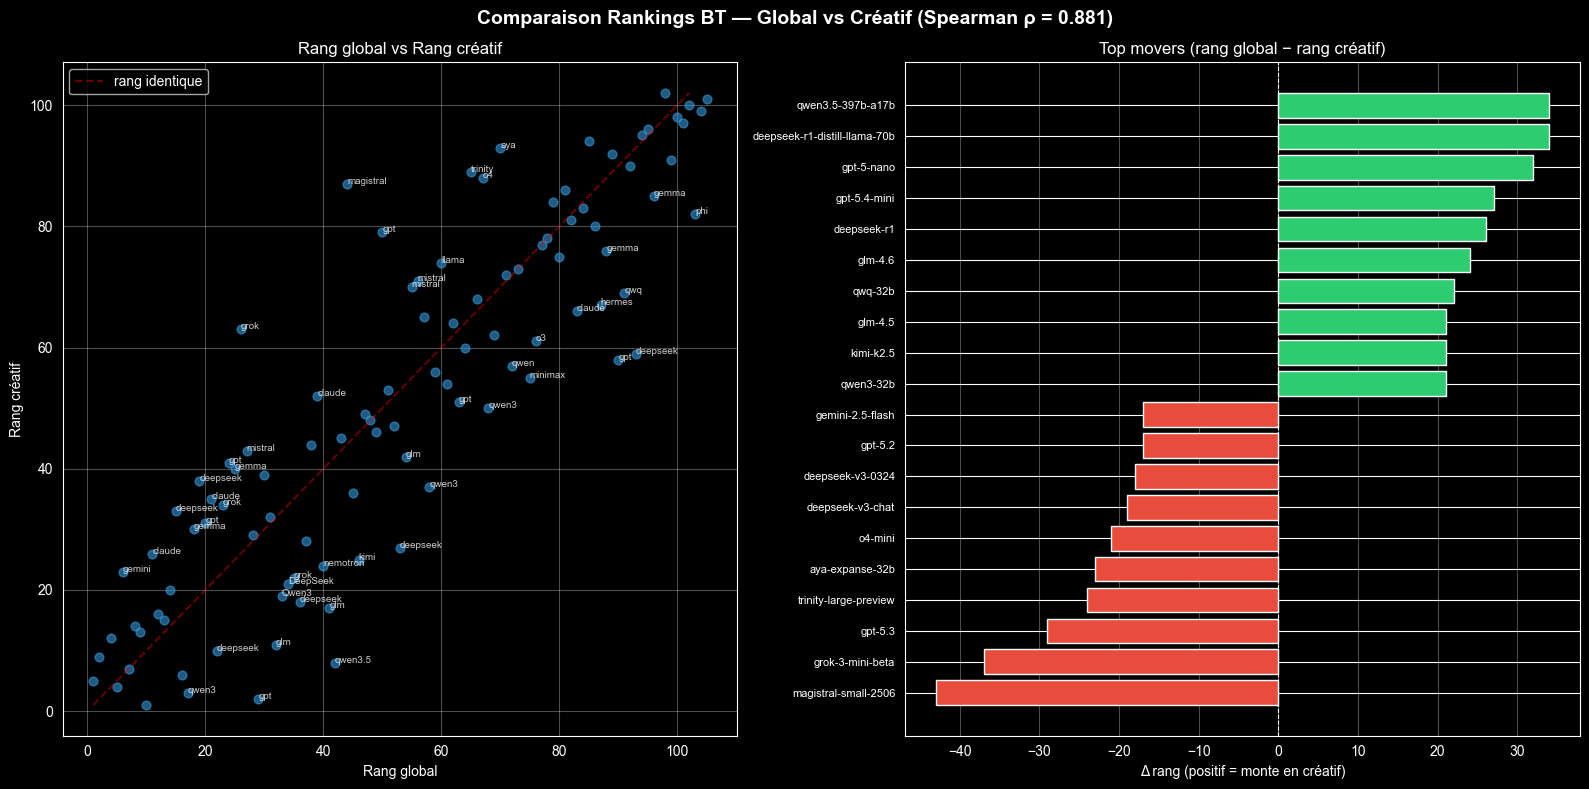

In [318]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle(f"Comparaison Rankings BT — Global vs Créatif (Spearman ρ = {rho:.3f})",
             fontsize=14, fontweight='bold')

# --- Scatter rank global vs rank créatif ---
axes[0].scatter(ranking_merged['rank'], ranking_merged['rank_creative'],
                alpha=0.6, color='#3498db', s=40)

# Annoter les outliers (delta significatif)
outliers = ranking_merged[ranking_merged['delta_rank'].abs() > 10]
for _, row in outliers.iterrows():
    axes[0].annotate(
        row['model'].split('-')[0],  # nom court
        (row['rank'], row['rank_creative']),
        fontsize=7, alpha=0.8
    )

# Diagonale parfaite
max_rank = len(ranking_merged)
axes[0].plot([1, max_rank], [1, max_rank], 'r--', alpha=0.4, label='rang identique')
axes[0].set_xlabel("Rang global")
axes[0].set_ylabel("Rang créatif")
axes[0].set_title("Rang global vs Rang créatif")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Delta de rang — top movers ---
top_movers = pd.concat([
    ranking_merged.nlargest(10, 'delta_rank'),   # montent le plus
    ranking_merged.nsmallest(10, 'delta_rank')   # descendent le plus
]).sort_values('delta_rank')

colors = ['#e74c3c' if d < 0 else '#2ecc71' for d in top_movers['delta_rank']]
axes[1].barh(top_movers['model'], top_movers['delta_rank'], color=colors)
axes[1].axvline(0, color='white', linewidth=0.8, linestyle='--')
axes[1].set_title("Top movers (rang global − rang créatif)")
axes[1].set_xlabel("Δ rang (positif = monte en créatif)")
axes[1].tick_params(axis='y', labelsize=8)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

Les modèles de raisonnement (DeepSeek-R1, QwQ) semblent devenir surprenamant compétitifs sur le créatif, tandis que certains compactes non raisonnant  y perdent significativement.